<a href="https://colab.research.google.com/github/shivraj7/scalar/blob/main/Copy_of_L8_Opitmization4_Constrained_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def get_partial(func,x,y):
  delta =0.0000001
  fx = (func(x+delta,y) - func(x,y))/delta
  fy = (func(x,y+delta) - func(x,y))/delta
  return fx,fy

In [ ]:
def func(x,y):
  return x**2+y**2

In [ ]:
get_partial(func,1,2)

(2.0000001033082526, 4.000000091153311)

In [ ]:
x = [1,2,3] #-10 to 10 -->1to3
y = [1,2,3] #-10 to 10 -->1to3
np.meshgrid(x, y)

[array([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]]),
 array([[1, 1, 1],
        [2, 2, 2],
        [3, 3, 3]])]

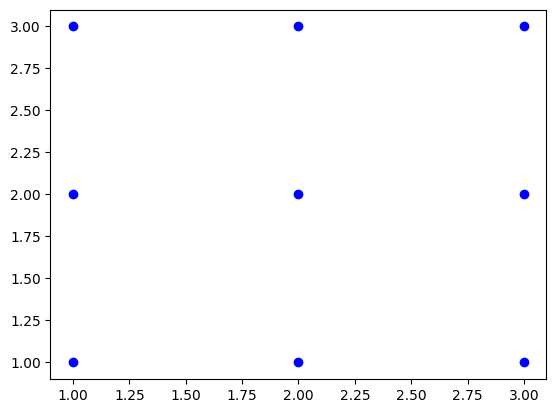

In [ ]:
X, Y =np.meshgrid(x, y)
plt.scatter(X, Y, color='blue')

In [ ]:
def get_grid():
  x = np.linspace(-10,10,20)
  y = np.linspace(-10,10,20)
  g1,g2 = np.meshgrid(x,y)
  return g1,g2

In [ ]:
g1_s,g2_s = get_grid()
g1_s.shape,g2_s.shape

((20, 20), (20, 20))

In [ ]:
#g1_s

In [ ]:
# g1 = [[1, 2, 3],
#       [4, 5, 6],
#       [7, 8, 9]]

# g2 = [[10, 11, 12],
#       [13, 14, 15],
#       [16, 17, 18]]

Outer Loop (Rows): The outer loop iterates over each row of the grid, obtaining both the index (rows_id) and the row data (row_x, row_y) simultaneously. For example, in the first iteration, rows_id = 0, row_x = [1, 2, 3], and row_y = [10, 11, 12].

Continuing with the first iteration of the outer loop: In the first iteration of the inner loop, col_id = 0, x = 1, and y = 10. In the second iteration, col_id = 1, x = 2, and y = 11. In the third iteration, col_id = 2, x = 3, and y = 12.

In [ ]:
def get_partial_from_grad(func,g1,g2):
  U = np.zeros(g1.shape)
  V = np.zeros(g2.shape)
  for rows_id,(row_x,row_y) in enumerate(zip(g1,g2)):
    for col_id,(x,y) in enumerate(zip(row_x,row_y)):
      fx,fy = get_partial(func,x,y)
      U[rows_id,col_id] =fx
      V[rows_id,col_id] =fy
  return U,V

In [ ]:
xpos = 0
ypos = 0
x_vec = 1 #fx =
y_vec = 1 #fy

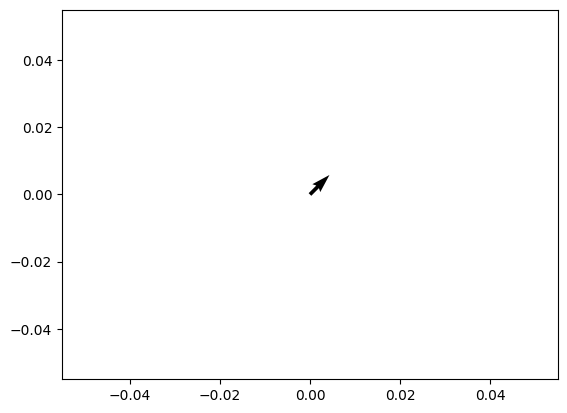

In [ ]:
fig,axes = plt.subplots()
axes.quiver(xpos,ypos,x_vec,y_vec)

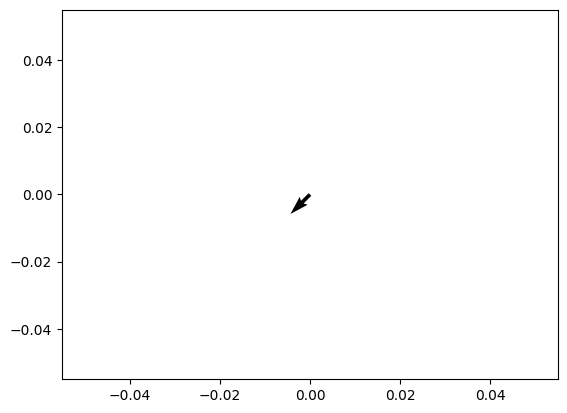

In [ ]:
fig,axes = plt.subplots()
axes.quiver(xpos,ypos,-x_vec,-y_vec)

In [ ]:
# xpos = g1
# ypos = g2
# x_vec = U
# y_vec =V
def plot_gradients(g1,g2,U,V):
  fig,axes = plt.subplots()
  axes.quiver(g1,g2,U,V)
  plt.show()

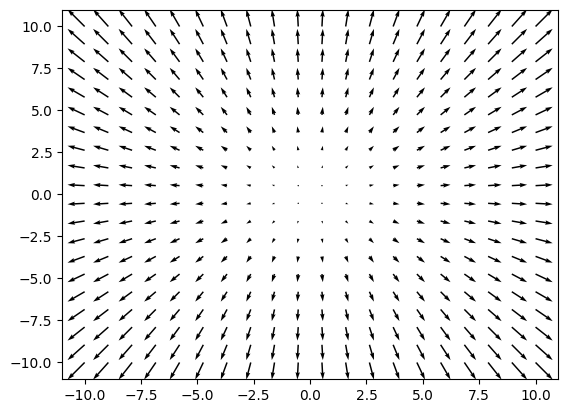

In [ ]:
#func = X**2 +Y**2
g1,g2 = get_grid() #-10 to 10 20 values
U,V = get_partial_from_grad(func,g1,g2)# will take every pair and will pass to partial der funct
plot_gradients(g1,g2,U,V)

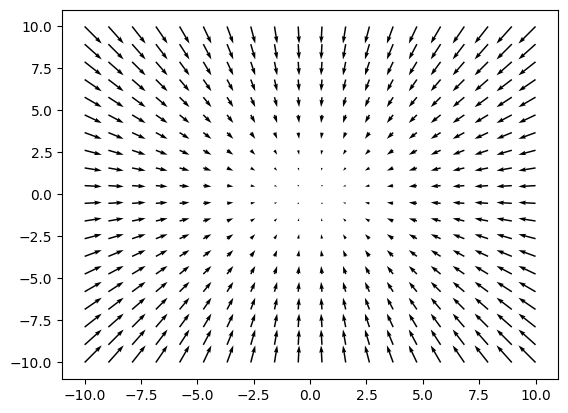

In [ ]:
#func = X**2 +Y**2
g1,g2 = get_grid() #-10 to 10 20 values
U,V = get_partial_from_grad(func,g1,g2)# will take every pair and will pass to partial der funct
plot_gradients(g1,g2,-U,-V)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

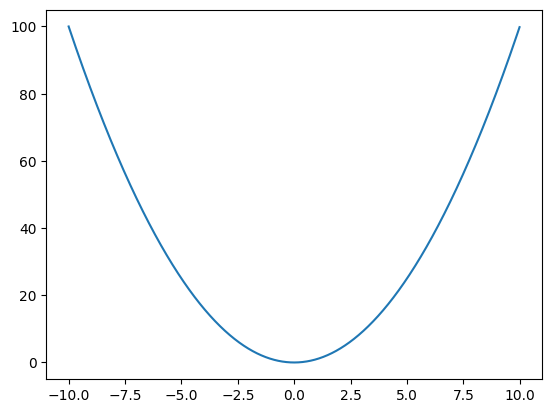

In [ ]:
## Try changing this
def f(x):
  return x**2
  ## Plot f(x)
x = np.arange(-10, 10, 0.01)
y = f(x)

plt.figure()
plt.plot(x, y)
plt.show()

In [ ]:
# This function takes derivative of f at point x
def derivative(x, f):
  delta = 0.0001
  return (f(x + delta) - f(x)) / delta

# This function does exactly one update to my parameter x
def one_step_gd(x, f, lr): # lr -> learning rate, same as \eta
  grad = derivative(x, f)
  new_x = x - lr * grad
  new_fx = f(new_x)
  return new_x, new_fx, grad

In [ ]:
## Define the initial random guess
x0 = -5
num_steps = 0 # Same as t in the update equation

# Let us save all our steps.
xs = []
fxs = []
grads = []

-4.000010000003158


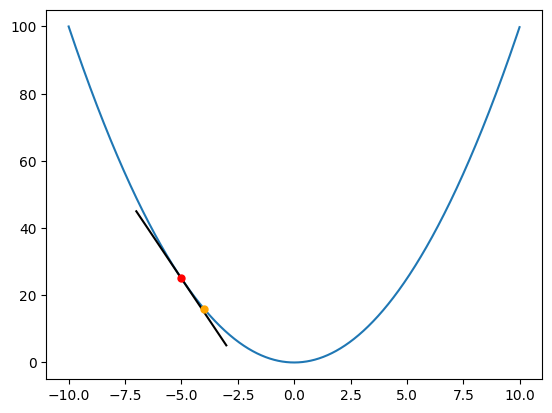

In [ ]:
## Lets plot!!
plt.figure()

# First, plot the function
x = np.arange(-10, 10, 0.01)
y = f(x)
plt.plot(x, y)

# Now apply gradient descent
new_x, new_fx, grad = one_step_gd(x0, f, 0.1)
xs.append(new_x)
fxs.append(new_fx)
grads.append(grad)
num_steps += 1

# Next, plot the old guess and the gradient at that point
t_c = f(x0) - grads[-1] * x0
delta = 2.
t_x = np.arange(x0 - delta, x0 + delta, 0.01)
t_y = grads[-1] * t_x + t_c
plt.plot(t_x, t_y, color="black")

# Next, plot the other guesses
for i in range(num_steps-1):
  plt.plot(xs[i], fxs[i], marker="o", markersize=5, markeredgecolor="green", markerfacecolor="green")

plt.plot(x0, f(x0), marker="o", markersize=5, markeredgecolor="red", markerfacecolor="red")
plt.plot(xs[-1], fxs[-1], marker="o", markersize=5, markeredgecolor="orange", markerfacecolor="orange")

print(new_x)
x0 = new_x
plt.show()